# 1일차
# pandas 시계열 데이터 처리

- 날짜형 변환
- DatetimeIndex
- resample / shift / rolling

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from datetime import datetime
plt.rcParams['figure.figsize'] = (10, 4)

In [3]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/05 판다스 넘파이 크롤링 실습/Day_04_file')
os.getcwd()

'/content/drive/MyDrive/Colab Notebooks/05 판다스 넘파이 크롤링 실습/Day_04_file'

## 1. datetime 기본 이해

### (1) datetime 오브젝트

In [3]:
now1 = datetime.now() # 현재 시간 1
print(now1)

2026-06-25 00:30:19.856820


In [4]:
now2 = datetime.today() # 현재 시간 2
print(now2)

2026-06-25 00:30:19.867106


In [5]:
t1 = datetime.now()
t2 = datetime(1970, 1, 1)
             # 년,  월, 일, 시, 분, 초
t3 = datetime(1970, 12, 12, 13, 24, 34)

print(t1)
print(t2)
print(t3)

2026-06-25 00:30:19.875754
1970-01-01 00:00:00
1970-12-12 13:24:34


### (2) datetime 오브젝트로 시간 계산하기

In [6]:
diff1 = t1 - t2  # 날짜 차이
print(diff1)

20629 days, 0:30:19.875754


In [7]:
type(diff1)

datetime.timedelta

In [8]:
diff2 = t2 - t1
print(diff2)

-20630 days, 23:29:40.124246


## 2. 문자열 날짜를 pandas 날짜형으로 변환하기

### (1) 문자열을 datetime 오브젝트로 변환하기

In [9]:
# 에볼라 바이러스 발병 데이터

ebola = pd.read_csv('country_timeseries.csv')

In [10]:
ebola.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali
0,1/5/2015,289,2776.0,NaN,10030.0,NaN,NaN,NaN,NaN,NaN,1786.0,NaN,2977.0,NaN,NaN,NaN,NaN,NaN
1,1/4/2015,288,2775.0,NaN,9780.0,NaN,NaN,NaN,NaN,NaN,1781.0,NaN,2943.0,NaN,NaN,NaN,NaN,NaN
2,1/3/2015,287,2769.0,8166.0,9722.0,NaN,NaN,NaN,NaN,NaN,1767.0,3496.0,2915.0,NaN,NaN,NaN,NaN,NaN
3,1/2/2015,286,NaN,8157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3496.0,NaN,NaN,NaN,NaN,NaN,NaN
4,12/31/2014,284,2730.0,8115.0,9633.0,NaN,NaN,NaN,NaN,NaN,1739.0,3471.0,2827.0,NaN,NaN,NaN,NaN,NaN


In [11]:
ebola.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 122 non-null    object 
 1   Day                  122 non-null    int64  
 2   Cases_Guinea         93 non-null     float64
 3   Cases_Liberia        83 non-null     float64
 4   Cases_SierraLeone    87 non-null     float64
 5   Cases_Nigeria        38 non-null     float64
 6   Cases_Senegal        25 non-null     float64
 7   Cases_UnitedStates   18 non-null     float64
 8   Cases_Spain          16 non-null     float64
 9   Cases_Mali           12 non-null     float64
 10  Deaths_Guinea        92 non-null     float64
 11  Deaths_Liberia       81 non-null     float64
 12  Deaths_SierraLeone   87 non-null     float64
 13  Deaths_Nigeria       38 non-null     float64
 14  Deaths_Senegal       22 non-null     float64
 15  Deaths_UnitedStates  18 non-null     flo

In [12]:
# 2-1-1

ebola['date_dt'] = pd.to_datetime(ebola['Date'])  # datetime 오브젝트를 이용해서 날짜 형식 수정

In [13]:
ebola.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali,date_dt
0,1/5/2015,289,2776.0,NaN,10030.0,NaN,NaN,NaN,NaN,NaN,1786.0,NaN,2977.0,NaN,NaN,NaN,NaN,NaN,2015-01-05
1,1/4/2015,288,2775.0,NaN,9780.0,NaN,NaN,NaN,NaN,NaN,1781.0,NaN,2943.0,NaN,NaN,NaN,NaN,NaN,2015-01-04
2,1/3/2015,287,2769.0,8166.0,9722.0,NaN,NaN,NaN,NaN,NaN,1767.0,3496.0,2915.0,NaN,NaN,NaN,NaN,NaN,2015-01-03
3,1/2/2015,286,NaN,8157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3496.0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-02
4,12/31/2014,284,2730.0,8115.0,9633.0,NaN,NaN,NaN,NaN,NaN,1739.0,3471.0,2827.0,NaN,NaN,NaN,NaN,NaN,2014-12-31


In [14]:
ebola.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

In [15]:
# format: 원본 날짜 읽는 순서 지정
test_df1 = pd.DataFrame({'order_day': ['01/01/15', '02/01/15', '03/01/15']})
                                                                                # 주어진 값을 아래대로 읽게 설정함
test_df1['date_dt1'] = pd.to_datetime(test_df1['order_day'], format='%d/%m/%y') # 일/월/년
test_df1['date_dt2'] = pd.to_datetime(test_df1['order_day'], format='%m/%d/%y') # 월/일/년
test_df1['date_dt3'] = pd.to_datetime(test_df1['order_day'], format='%y/%m/%d') # 년/월/일
test_df1

,order_day,date_dt1,date_dt2,date_dt3
0,01/01/15,2015-01-01,2015-01-01,2001-01-15
1,02/01/15,2015-01-02,2015-02-01,2002-01-15
2,03/01/15,2015-01-03,2015-03-01,2003-01-15


In [16]:
# 구분자도 원본과 맞춤
test_df2 = pd.DataFrame({'order_day': ['01-01-15', '02-01-15', '03-01-15']})
test_df2['date_dt'] = pd.to_datetime(test_df2['order_day'], format='%d-%m-%y')
test_df2

,order_day,date_dt
0,01-01-15,2015-01-01
1,02-01-15,2015-01-02
2,03-01-15,2015-01-03


### (2) read_csv에서 날짜 컬럼 바로 변환하기

In [17]:
# CSV를 읽으면서 Date를 날짜형으로 변환
ebola1 = pd.read_csv('country_timeseries.csv', parse_dates=['Date'])
ebola1.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali
0,2015-01-05,289,2776.0,NaN,10030.0,NaN,NaN,NaN,NaN,NaN,1786.0,NaN,2977.0,NaN,NaN,NaN,NaN,NaN
1,2015-01-04,288,2775.0,NaN,9780.0,NaN,NaN,NaN,NaN,NaN,1781.0,NaN,2943.0,NaN,NaN,NaN,NaN,NaN
2,2015-01-03,287,2769.0,8166.0,9722.0,NaN,NaN,NaN,NaN,NaN,1767.0,3496.0,2915.0,NaN,NaN,NaN,NaN,NaN
3,2015-01-02,286,NaN,8157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3496.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-31,284,2730.0,8115.0,9633.0,NaN,NaN,NaN,NaN,NaN,1739.0,3471.0,2827.0,NaN,NaN,NaN,NaN,NaN


In [18]:
ebola1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    datetime64[ns]
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

## 3. 날짜 정보 추출하기
### (1) datetime 오브젝트에서 날짜 정보 추출하기

In [19]:
# 문자열 Series → 날짜형 Series
date_series = pd.Series(['2018-05-16', '2018-05-17', '2018-05-18'])
d1 = pd.to_datetime(date_series)
d1

,0
0,2018-05-16
1,2018-05-17
2,2018-05-18


In [20]:
d1[0] # 한번에 처리할 수는 없음

Timestamp('2018-05-16 00:00:00')

In [21]:
d1[0].year

2018

In [22]:
d1[0].month

5

In [23]:
d1[0].day

16

### (2) dt 접근자 사용하기

In [24]:
# Date 컬럼을 날짜형으로 변환
ebola = pd.read_csv('country_timeseries.csv')
ebola['date_dt'] = pd.to_datetime(ebola['Date']) # 2-1-1 에서도 date_dt 사용
ebola[['Date', 'date_dt']].head()


,Date,date_dt
0,1/5/2015,2015-01-05
1,1/4/2015,2015-01-04
2,1/3/2015,2015-01-03
3,1/2/2015,2015-01-02
4,12/31/2014,2014-12-31


In [25]:
ebola['date_dt'][3]

Timestamp('2015-01-02 00:00:00')

In [26]:
ebola['date_dt'][3].year

2015

In [27]:
ebola['date_dt'][3].month

1

In [28]:
ebola['date_dt'][3].day

2

In [29]:
# 연도 추출
ebola['year'] = ebola['date_dt'].dt.year  # 별도의 속성값 생성 및 적용
ebola[['Date', 'date_dt', 'year']].head() # 확인

,Date,date_dt,year
0,1/5/2015,2015-01-05,2015
1,1/4/2015,2015-01-04,2015
2,1/3/2015,2015-01-03,2015
3,1/2/2015,2015-01-02,2015
4,12/31/2014,2014-12-31,2014


In [30]:
# 월/일 추출
ebola['month'], ebola['day'] = (ebola['date_dt'].dt.month, ebola['date_dt'].dt.day) # 별도의 속성값 생성 및 적용
ebola[['Date', 'date_dt', 'year', 'month', 'day']].head()                           # 확인

,Date,date_dt,year,month,day
0,1/5/2015,2015-01-05,2015,1,5
1,1/4/2015,2015-01-04,2015,1,4
2,1/3/2015,2015-01-03,2015,1,3
3,1/2/2015,2015-01-02,2015,1,2
4,12/31/2014,2014-12-31,2014,12,31


In [31]:
ebola.info() # 늘어남

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

### (3) 최초 발병일 기준으로 경과일 계산하기

In [32]:
# 마지막 5행, 앞쪽 5열
ebola.iloc[-5:, :5]       # 필요한 것(최초 발병일 확인)

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
117,3/27/2014,5,103.0,8.0,6.0
118,3/26/2014,4,86.0,NaN,NaN
119,3/25/2014,3,86.0,NaN,NaN
120,3/24/2014,2,86.0,NaN,NaN
121,3/22/2014,0,49.0,NaN,NaN


In [33]:
# 가장 이른 날짜
ebola['date_dt'].min()       # min = 시작일

Timestamp('2014-03-22 00:00:00')

In [34]:
type(ebola['date_dt'].min()) # 데이터 타입이 뭔지 확인(dt 적용하기 위해 확인차)

pandas._libs.tslibs.timestamps.Timestamp

In [35]:
# 최초 날짜 기준 경과 시간
ebola['outbreak_d'] = ebola['date_dt'] - ebola['date_dt'].min()
ebola[['Date', 'Day', 'outbreak_d']].head()

,Date,Day,outbreak_d
0,1/5/2015,289,289 days
1,1/4/2015,288,288 days
2,1/3/2015,287,287 days
3,1/2/2015,286,286 days
4,12/31/2014,284,284 days


## 4. 은행 파산 데이터로 연도/분기 집계하기

### (1) 파산 은행 수 집계

In [36]:
banks_no_dates = pd.read_csv('banklist.csv')
banks_no_dates.head()

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",26-May-17,26-Jul-17
1,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,5-May-17,26-Jul-17
2,First NBC Bank,New Orleans,LA,58302,Whitney Bank,28-Apr-17,26-Jul-17
3,Proficio Bank,Cottonwood Heights,UT,35495,Cache Valley Bank,3-Mar-17,18-May-17
4,Seaway Bank and Trust Company,Chicago,IL,19328,State Bank of Texas,27-Jan-17,18-May-17


In [37]:
banks_no_dates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              553 non-null    object
 1   City                   553 non-null    object
 2   ST                     553 non-null    object
 3   CERT                   553 non-null    int64 
 4   Acquiring Institution  553 non-null    object
 5   Closing Date           553 non-null    object
 6   Updated Date           553 non-null    object
dtypes: int64(1), object(6)
memory usage: 30.4+ KB


In [38]:
# 날짜 컬럼을 읽으면서 변환
banks = pd.read_csv('banklist.csv', parse_dates=['Closing Date', 'Updated Date'],date_format='%d-%b-%y') # Datetime으로 타입 변환 # %b : Apr 등 축약어 # %m : 숫자표기
banks.head()

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",2017-05-26,2017-07-26
1,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,2017-05-05,2017-07-26
2,First NBC Bank,New Orleans,LA,58302,Whitney Bank,2017-04-28,2017-07-26
3,Proficio Bank,Cottonwood Heights,UT,35495,Cache Valley Bank,2017-03-03,2017-05-18
4,Seaway Bank and Trust Company,Chicago,IL,19328,State Bank of Texas,2017-01-27,2017-05-18


In [39]:
banks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Bank Name              553 non-null    object        
 1   City                   553 non-null    object        
 2   ST                     553 non-null    object        
 3   CERT                   553 non-null    int64         
 4   Acquiring Institution  553 non-null    object        
 5   Closing Date           553 non-null    datetime64[ns]
 6   Updated Date           553 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 30.4+ KB


In [40]:
# 분기/연도 컬럼 추가
banks['closing_quarter'], banks['closing_year'] = (
    banks['Closing Date'].dt.quarter,
    banks['Closing Date'].dt.year
)
banks[['Bank Name', 'Closing Date', 'closing_quarter', 'closing_year']].head()

,Bank Name,Closing Date,closing_quarter,closing_year
0,Fayette County Bank,2017-05-26,2,2017
1,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",2017-05-05,2,2017
2,First NBC Bank,2017-04-28,2,2017
3,Proficio Bank,2017-03-03,1,2017
4,Seaway Bank and Trust Company,2017-01-27,1,2017


In [41]:
# 연도별 건수
closing_year = banks.groupby(['closing_year']).size() # 기준 묶고, 몇개인지 계산
closing_year

,0
closing_year,
2000,2
2001,4
2002,11
2003,3
2004,4
2007,3
2008,25
2009,140
2010,157


In [42]:
# 연도+분기별 건수
closing_year_q = banks.groupby(['closing_year', 'closing_quarter']).size() # 기준을 구별하여 계산
closing_year_q.head()

closing_year  closing_quarter
2000          4                  2
2001          1                  1
              2                  1
              3                  2
2002          1                  6
dtype: int64

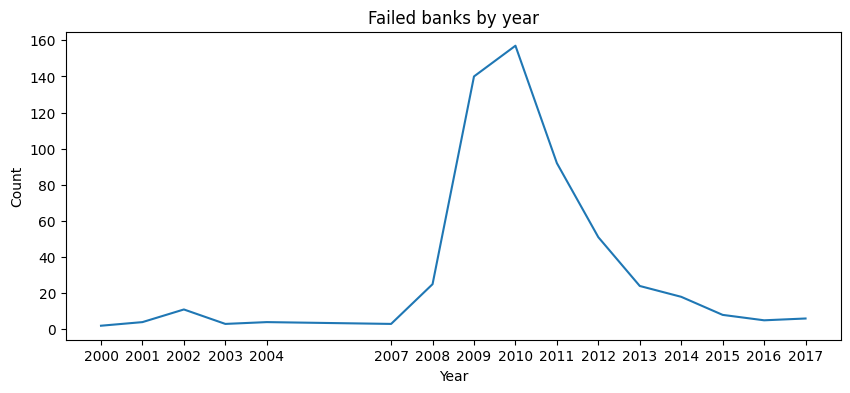

In [43]:
# 연도별 파산 은행 수 그래프
closing_year.plot(title='Failed banks by year')
plt.xticks(closing_year.index)
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

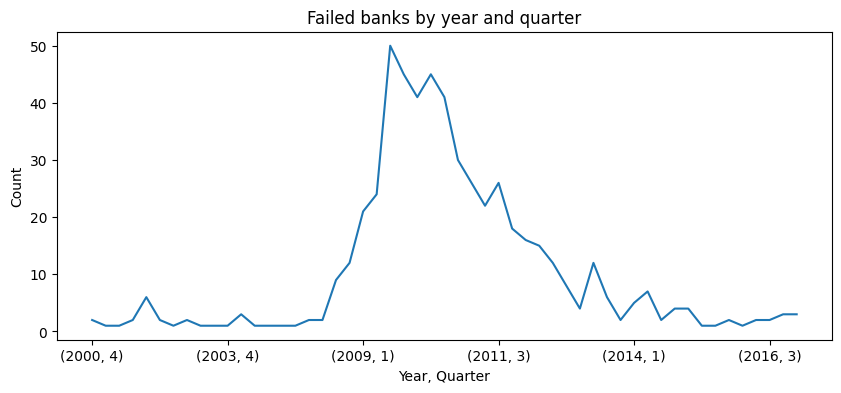

In [44]:
# 분기별 파산 은행 수 그래프
closing_year_q.plot(title='Failed banks by year and quarter')
plt.xlabel('Year, Quarter')
plt.ylabel('Count')
plt.show()

## 5. 주식 데이터에서 날짜 인덱스 사용하기

### (1) yfinance로 테슬라 주가 데이터 가져오기

- TSLA 주가 다운로드
- CSV 저장
- Date 컬럼을 시계열 기준으로 사용

In [45]:
# yfinance 설치
#%pip install yfinance

In [1]:
# TSLA 주가 다운로드 후 CSV 저장
import yfinance as yf

tesla = yf.download(         # 전처리
    'TSLA',
    start='2010-01-01',
    end='2017-12-31',
    auto_adjust=False,
    progress=False,            # 진행과정 보여주는 코드
    multi_level_index=False  # 전처리
)

print(tesla.head())          # 기본적으로 DATE 가 인덱스임
tesla = tesla.reset_index()  # 그걸 초기화 해줌
tesla

            Adj Close     Close      High       Low      Open     Volume
Date                                                                    
2010-06-29   1.592667  1.592667  1.666667  1.169333  1.266667  281494500
2010-06-30   1.588667  1.588667  2.028000  1.553333  1.719333  257806500
2010-07-01   1.464000  1.464000  1.728000  1.351333  1.666667  123282000
2010-07-02   1.280000  1.280000  1.540000  1.247333  1.533333   77097000
2010-07-06   1.074000  1.074000  1.333333  1.055333  1.333333  103003500


,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333,103003500
...,...,...,...,...,...,...,...
1886,2017-12-22,21.680000,21.680000,22.061333,21.654667,21.967333,63237000
1887,2017-12-26,21.152666,21.152666,21.596001,21.105333,21.588667,65676000
1888,2017-12-27,20.775999,20.775999,21.178667,20.716667,21.066668,70681500
1889,2017-12-28,21.024000,21.024000,21.054667,20.636000,20.783333,64744500


In [4]:
tesla.info()              # Date 가 Datetime으로 되어있음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891 entries, 0 to 1890
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1891 non-null   datetime64[ns]
 1   Adj Close  1891 non-null   float64       
 2   Close      1891 non-null   float64       
 3   High       1891 non-null   float64       
 4   Low        1891 non-null   float64       
 5   Open       1891 non-null   float64       
 6   Volume     1891 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 103.5 KB


In [5]:
# 2010년 6월만 필터링
tesla_2010_06 = tesla[(tesla['Date'].dt.year == 2010) & (tesla['Date'].dt.month == 6)]
tesla_2010_06.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333,257806500


In [6]:
# Date를 인덱스로 설정
tesla = tesla.set_index('Date')
tesla.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667,281494500
2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333,257806500
2010-07-01,1.464000,1.464000,1.728000,1.351333,1.666667,123282000
2010-07-02,1.280000,1.280000,1.540000,1.247333,1.533333,77097000
2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333,103003500


In [7]:
tesla.index

DatetimeIndex(['2010-06-29', '2010-06-30', '2010-07-01', '2010-07-02',
               '2010-07-06', '2010-07-07', '2010-07-08', '2010-07-09',
               '2010-07-12', '2010-07-13',
               ...
               '2017-12-15', '2017-12-18', '2017-12-19', '2017-12-20',
               '2017-12-21', '2017-12-22', '2017-12-26', '2017-12-27',
               '2017-12-28', '2017-12-29'],
              dtype='datetime64[ns]', name='Date', length=1891, freq=None)

In [8]:
# 연도 문자열로 조회
tesla.loc['2015'].iloc[:5, :5]

,Adj Close,Close,High,Low,Open
Date,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333


In [9]:
# 연-월 문자열로 조회
tesla.loc['2010-06'].iloc[:, :5]

,Adj Close,Close,High,Low,Open
Date,,,,,
2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667
2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333


In [10]:
# 시작일 기준 경과 시간
tesla['ref_date'] = tesla.index - tesla.index.min()
tesla.iloc[:5, :5]

,Adj Close,Close,High,Low,Open
Date,,,,,
2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667
2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333
2010-07-01,1.464000,1.464000,1.728000,1.351333,1.666667
2010-07-02,1.280000,1.280000,1.540000,1.247333,1.533333
2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333


In [11]:
# ref_date 인덱스
tesla_ref = tesla.reset_index().set_index('ref_date')
tesla_ref.iloc[:5, :5]

,Date,Adj Close,Close,High,Low
ref_date,,,,,
0 days,2010-06-29,1.592667,1.592667,1.666667,1.169333
1 days,2010-06-30,1.588667,1.588667,2.028000,1.553333
2 days,2010-07-01,1.464000,1.464000,1.728000,1.351333
3 days,2010-07-02,1.280000,1.280000,1.540000,1.247333
7 days,2010-07-06,1.074000,1.074000,1.333333,1.055333


In [12]:
# 기간 문자열로 조회
tesla_ref.loc['5 days':].head()

,Date,Adj Close,Close,High,Low,Open,Volume
ref_date,,,,,,,
7 days,2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333,103003500
8 days,2010-07-07,1.053333,1.053333,1.108667,0.998667,1.093333,103825500
9 days,2010-07-08,1.164000,1.164000,1.168000,1.038000,1.076000,115671000
10 days,2010-07-09,1.160000,1.160000,1.193333,1.103333,1.172000,60759000
13 days,2010-07-12,1.136667,1.136667,1.204667,1.133333,1.196667,33037500


# 2일차 시작

## 6. 에볼라 확산 속도 비교

- 목표: 나라별 확산 흐름을 같은 출발선에서 비교
- 핵심: Date 인덱스, reindex, shift, Day 인덱스

### (1) 데이터 준비하기

In [13]:
# 날짜 정렬 후 분석 컬럼 선택
ebola = pd.read_csv('country_timeseries.csv', parse_dates=['Date'])

ebola = ebola.sort_values('Date')

ebola = ebola.set_index('Date')

case_cols = ['Cases_Guinea', 'Cases_Liberia', 'Cases_SierraLeone']
ebola[case_cols].head()

,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
Date,,,
2014-03-22,49.0,NaN,NaN
2014-03-24,86.0,NaN,NaN
2014-03-25,86.0,NaN,NaN
2014-03-26,86.0,NaN,NaN
2014-03-27,103.0,8.0,6.0


### (2) 실제 날짜 기준 그래프

- x축: 실제 날짜
- 한계: 나라별 시작 시점이 다름

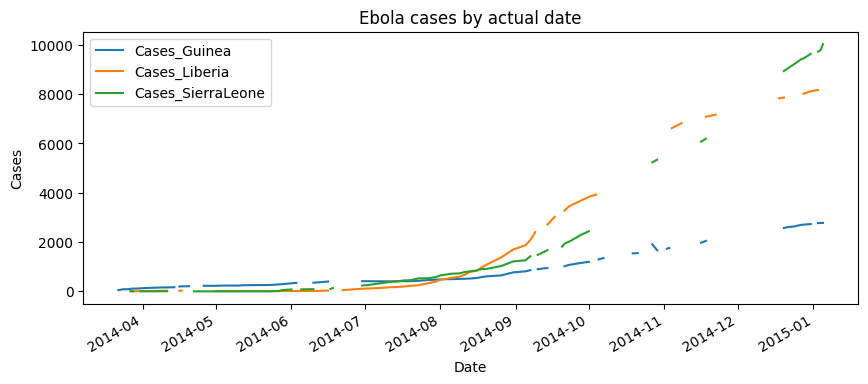

In [14]:
# 실제 날짜 기준 그래프
ebola[case_cols].plot(title='Ebola cases by actual date')

plt.xlabel('Date')
plt.ylabel('Cases')
plt.show()

### (3) shift 문법 확인

- `shift(1)`: 값을 한 칸 아래로 이동
- `shift(-1)`: 값을 한 칸 위로 이동

In [15]:
# shift(1): 값을 한 칸 아래로 이동
guinea = ebola['Cases_Guinea'].dropna()

shift_example = pd.DataFrame({
    'original': guinea,
    'shift_1': guinea.shift(1)
})
shift_example.head(10)

,original,shift_1
Date,,
2014-03-22,49.0,NaN
2014-03-24,86.0,49.0
2014-03-25,86.0,86.0
2014-03-26,86.0,86.0
2014-03-27,103.0,86.0
2014-03-28,112.0,103.0
2014-03-29,112.0,112.0
2014-03-31,122.0,112.0
2014-04-01,127.0,122.0


### (4) 날짜 축 정리

- `date_range`: 전체 날짜 생성
- `reindex`: 빠진 날짜 포함

In [20]:
# 전체 날짜 축으로 맞춤
full_dates = pd.date_range(ebola.index.min(), ebola.index.max())
full_dates

DatetimeIndex(['2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31',
               ...
               '2014-12-27', '2014-12-28', '2014-12-29', '2014-12-30',
               '2014-12-31', '2015-01-01', '2015-01-02', '2015-01-03',
               '2015-01-04', '2015-01-05'],
              dtype='datetime64[ns]', length=290, freq='D')

In [22]:
ebola_daily = ebola.reindex(full_dates)  # 누락된 날짜 생성
ebola_daily[case_cols].head(10)

,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
2014-03-22,49.0,NaN,NaN
2014-03-23,NaN,NaN,NaN
2014-03-24,86.0,NaN,NaN
2014-03-25,86.0,NaN,NaN
2014-03-26,86.0,NaN,NaN
2014-03-27,103.0,8.0,6.0
2014-03-28,112.0,3.0,2.0
2014-03-29,112.0,7.0,NaN
2014-03-30,NaN,NaN,NaN
2014-03-31,122.0,8.0,2.0


### (5) 나라별 첫 관측 시점

- `first_valid_index`: 첫 값이 있는 날짜
- `shift_days`: 기준일과의 날짜 차이

In [23]:
# 나라별 첫 관측일 차이 계산
first_valid = ebola_daily[case_cols].apply(pd.Series.first_valid_index)

first_valid

,0
Cases_Guinea,2014-03-22
Cases_Liberia,2014-03-27
Cases_SierraLeone,2014-03-27


In [27]:
base_date = first_valid.min()
base_date

Timestamp('2014-03-22 00:00:00')

In [25]:
shift_days = (first_valid - base_date).dt.days
shift_days

,0
Cases_Guinea,0
Cases_Liberia,5
Cases_SierraLeone,5


### (6) shift로 출발선 맞추기

- 시작이 늦은 나라는 앞으로 당김
- 같은 Day 기준으로 비교 준비

In [28]:
# 시작일 차이만큼 앞으로 당김
shifted_cases = {}

for col in case_cols:
    d = int(shift_days[col])

    shifted_cases[col] = ebola_daily[col].shift(-d)

ebola_shifted = pd.DataFrame(shifted_cases)
ebola_shifted

,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
2014-03-22,49.0,8.0,6.0
2014-03-23,NaN,3.0,2.0
2014-03-24,86.0,7.0,NaN
2014-03-25,86.0,NaN,NaN
2014-03-26,86.0,8.0,2.0
...,...,...,...
2015-01-01,NaN,NaN,NaN
2015-01-02,NaN,NaN,NaN
2015-01-03,2769.0,NaN,NaN
2015-01-04,2775.0,NaN,NaN


In [29]:
ebola_shifted = ebola_shifted.dropna(how='all')
ebola_shifted.head(10)

,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
2014-03-22,49.0,8.0,6.0
2014-03-23,NaN,3.0,2.0
2014-03-24,86.0,7.0,NaN
2014-03-25,86.0,NaN,NaN
2014-03-26,86.0,8.0,2.0
2014-03-27,103.0,8.0,2.0
2014-03-28,112.0,NaN,NaN
2014-03-29,112.0,NaN,NaN
2014-03-30,NaN,18.0,2.0
2014-03-31,122.0,NaN,NaN


### (7) Day 기준 비교

- 실제 날짜 대신 경과일 사용
- Day 0부터 확산 흐름 비교

In [32]:
# Day 인덱스 생성

ebola_shifted['Day'] = range(len(ebola_shifted))
ebola_shifted = ebola_shifted.set_index('Day')
ebola_shifted[case_cols].head()

,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
Day,,,
0,49.0,8.0,6.0
1,NaN,3.0,2.0
2,86.0,7.0,NaN
3,86.0,NaN,NaN
4,86.0,8.0,2.0


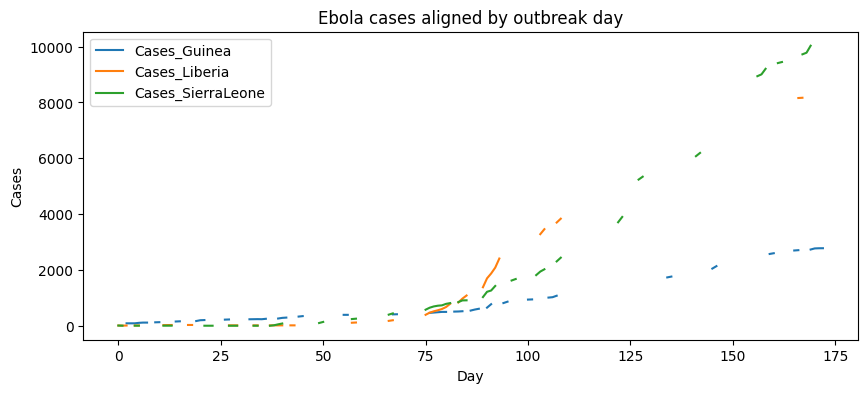

In [33]:
# Day 기준 그래프
ebola_shifted[case_cols].plot(title='Ebola cases aligned by outbreak day')

plt.xlabel('Day')
plt.ylabel('Cases')
plt.show()

### 정리

- 실제 날짜 기준: 달력 흐름
- Day 기준: 시작점 맞춘 흐름
- shift: 시계열 값을 이동

## 7. DatetimeIndex와 리샘플링

### (1) DatetimeIndex

In [34]:
# 날짜 인덱스 Series 생성
dates = pd.date_range('2024-01-01', periods=6)
ts = pd.Series(np.arange(6), index=dates)
ts

,0
2024-01-01,0
2024-01-02,1
2024-01-03,2
2024-01-04,3
2024-01-05,4
2024-01-06,5


In [35]:
ts.index

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06'],
              dtype='datetime64[ns]', freq='D')

In [36]:
# 날짜 문자열로 조회
ts['2024-01-03']

np.int64(2)

In [37]:
# 월 단위 문자열로 조회
ts['2024-01']

,0
2024-01-01,0
2024-01-02,1
2024-01-03,2
2024-01-04,3
2024-01-05,4
2024-01-06,5


### (2) 리샘플링과 다운샘플링

In [38]:
# 1분 간격(min) 시계열 생성
rng = pd.date_range('2024-01-01', periods=12, freq='min')
ts = pd.Series(np.arange(12), index=rng)
ts

,0
2024-01-01 00:00:00,0
2024-01-01 00:01:00,1
2024-01-01 00:02:00,2
2024-01-01 00:03:00,3
2024-01-01 00:04:00,4
2024-01-01 00:05:00,5
2024-01-01 00:06:00,6
2024-01-01 00:07:00,7
2024-01-01 00:08:00,8
2024-01-01 00:09:00,9


In [39]:
# '5min': 5분 단위로 묶기
ts.resample('5min').sum()

,0
2024-01-01 00:00:00,10
2024-01-01 00:05:00,35
2024-01-01 00:10:00,21


In [40]:
# '5min': 5분 단위 평균
ts.resample('5min').mean()

,0
2024-01-01 00:00:00,2.0
2024-01-01 00:05:00,7.0
2024-01-01 00:10:00,10.5


In [41]:
# closed: 경계 포함 방향, label: 결과 시간 라벨 위치
ts.resample('5min', closed='right', label='right').sum()

,0
2024-01-01 00:00:00,0
2024-01-01 00:05:00,15
2024-01-01 00:10:00,40
2024-01-01 00:15:00,11


### (3) OHLC 리샘플링

- 1분 데이터를 5분 단위 OHLC로 집계
- 참고: 실제 주가 종가에도 같은 방식 적용 가능

In [42]:
# '5min' 단위 open/high/low/close 집계
ts.resample('5min').ohlc()

,open,high,low,close
2024-01-01 00:00:00,0,4,0,4
2024-01-01 00:05:00,5,9,5,9
2024-01-01 00:10:00,10,11,10,11


In [43]:
# 테슬라 데이터를 Date 인덱스로 설정
tesla = pd.read_csv('tesla_stock_yfinance.csv', parse_dates=['Date'])
tesla = tesla.set_index('Date').sort_index()
tesla[['Open', 'High', 'Low', 'Close', 'Volume']].head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-06-29,1.266667,1.666667,1.169333,1.592667,281494500
2010-06-30,1.719333,2.028000,1.553333,1.588667,257806500
2010-07-01,1.666667,1.728000,1.351333,1.464000,123282000
2010-07-02,1.533333,1.540000,1.247333,1.280000,77097000
2010-07-06,1.333333,1.333333,1.055333,1.074000,103003500


In [44]:
# 'ME': 월말 기준으로 묶기
tesla['Close'].resample('ME').ohlc().head()

,open,high,low,close
Date,,,,
2010-06-30,1.592667,1.592667,1.588667,1.588667
2010-07-31,1.464000,1.464000,1.053333,1.329333
2010-08-31,1.394667,1.463333,1.173333,1.298667
2010-09-30,1.363333,1.465333,1.304000,1.360667
2010-10-31,1.373333,1.456000,1.336667,1.456000


### (4) GroupBy를 사용한 리샘플링

- 날짜 인덱스의 월/요일 기준 그룹화
- 참고: 실제 데이터도 같은 방식으로 그룹화 가능

In [48]:
ts

,0
2024-01-01 00:00:00,0
2024-01-01 00:01:00,1
2024-01-01 00:02:00,2
2024-01-01 00:03:00,3
2024-01-01 00:04:00,4
2024-01-01 00:05:00,5
2024-01-01 00:06:00,6
2024-01-01 00:07:00,7
2024-01-01 00:08:00,8
2024-01-01 00:09:00,9


In [49]:
# 날짜 인덱스에서 월을 꺼내 평균 계산
ts.groupby(lambda x: x.month).mean()

,0
1,5.5


In [46]:
# 날짜 인덱스에서 요일 번호를 꺼내 평균 계산
ts.groupby(lambda x: x.weekday()).mean()

,0
0,5.5


In [47]:
# 테슬라 종가를 월 기준으로 평균 집계
tesla.groupby(lambda x: x.month)['Close'].mean()

,Close
Date,
1,8.503504
2,8.952928
3,9.557377
4,10.226310
5,10.558425
6,11.559158
7,10.381179
8,10.747562
9,11.084252


## 8. 업샘플링과 결측값 채우기

### (1) 업샘플링과 보간

- 주간 데이터 → 일별 데이터
- 새로 생긴 날짜는 결측값 발생
- `ffill()`로 이전 값 채우기

In [50]:
frame = pd.DataFrame(
    np.random.randn(2, 4),
    index=pd.date_range('1/1/2000', periods=2, freq='W-WED'),  # W-WED: 매주 수요일
    columns=['Colorado', 'Texas', 'New York', 'Ohio']
)
frame

,Colorado,Texas,New York,Ohio
2000-01-05,0.771796,-0.445845,0.129808,0.222264
2000-01-12,-0.358139,-0.803431,1.853505,0.621085


In [51]:
# 'D': 일 단위 빈도, 새 날짜 값은 NaN
frame.resample('D').asfreq()

,Colorado,Texas,New York,Ohio
2000-01-05,0.771796,-0.445845,0.129808,0.222264
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.358139,-0.803431,1.853505,0.621085


In [52]:
# 'D': 일 단위로 바꾼 뒤 이전 값으로 채움
frame.resample('D').ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,0.771796,-0.445845,0.129808,0.222264
2000-01-06,0.771796,-0.445845,0.129808,0.222264
2000-01-07,0.771796,-0.445845,0.129808,0.222264
2000-01-08,0.771796,-0.445845,0.129808,0.222264
2000-01-09,0.771796,-0.445845,0.129808,0.222264
2000-01-10,0.771796,-0.445845,0.129808,0.222264
2000-01-11,0.771796,-0.445845,0.129808,0.222264
2000-01-12,-0.358139,-0.803431,1.853505,0.621085


In [53]:
# limit=2: 최대 2칸까지만 이전 값으로 채움
frame.resample('D').ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,0.771796,-0.445845,0.129808,0.222264
2000-01-06,0.771796,-0.445845,0.129808,0.222264
2000-01-07,0.771796,-0.445845,0.129808,0.222264
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.358139,-0.803431,1.853505,0.621085


## 9. 시계열 그래프와 이동 창
### (1) 시계열 그래프

- 날짜 인덱스 기반 그래프
- 특정 기간 선택 가능

In [68]:
# 날짜 인덱스로 주가 데이터 읽기
close_px_all = pd.read_csv('stock_px.csv', parse_dates=True, index_col=0)
close_px_all.index.name = 'Date'
close_px_all.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2214 entries, 2003-01-02 to 2011-10-14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2214 non-null   float64
 1   MSFT    2214 non-null   float64
 2   XOM     2214 non-null   float64
 3   SPX     2214 non-null   float64
dtypes: float64(4)
memory usage: 86.5 KB


In [65]:
close_px = close_px_all[['AAPL', 'MSFT', 'XOM']]
close_px = close_px.resample('B').ffill()        # B: 영업일 기준
close_px.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2292 entries, 2003-01-02 to 2011-10-14
Freq: B
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2292 non-null   float64
 1   MSFT    2292 non-null   float64
 2   XOM     2292 non-null   float64
dtypes: float64(3)
memory usage: 71.6 KB


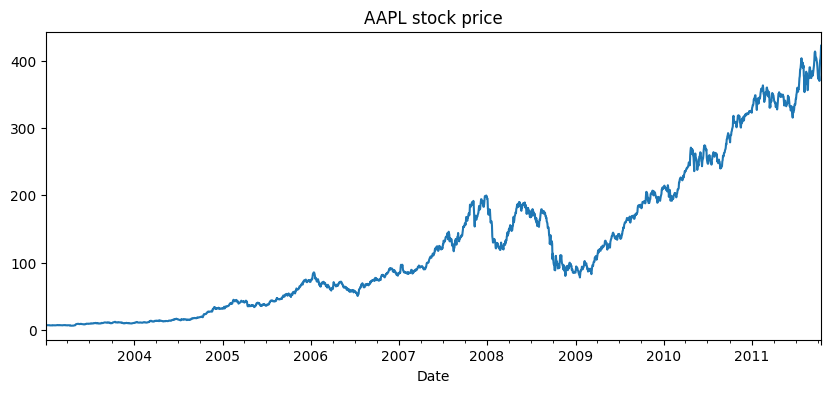

In [55]:
# AAPL 전체 기간 그래프
close_px['AAPL'].plot(title='AAPL stock price')
plt.show()

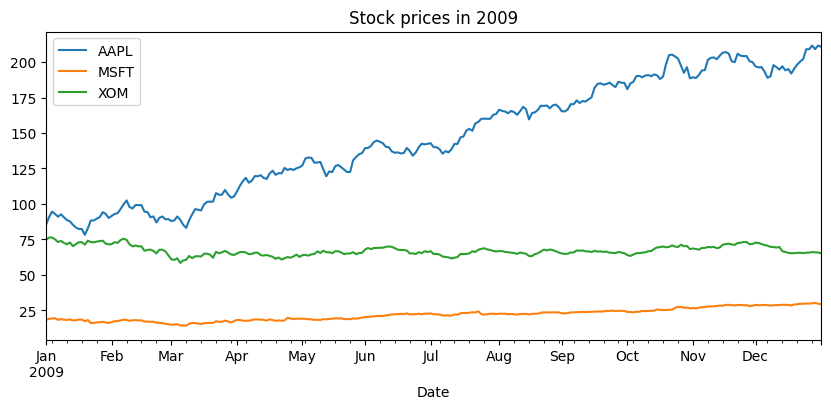

In [56]:
# 2009년 데이터만 그래프 확인
close_px.loc['2009'].plot(title='Stock prices in 2009')
plt.show()

### (2) 분기 단위 시계열 그래프

- 일별 데이터 → 분기 단위 데이터
- 큰 흐름 확인

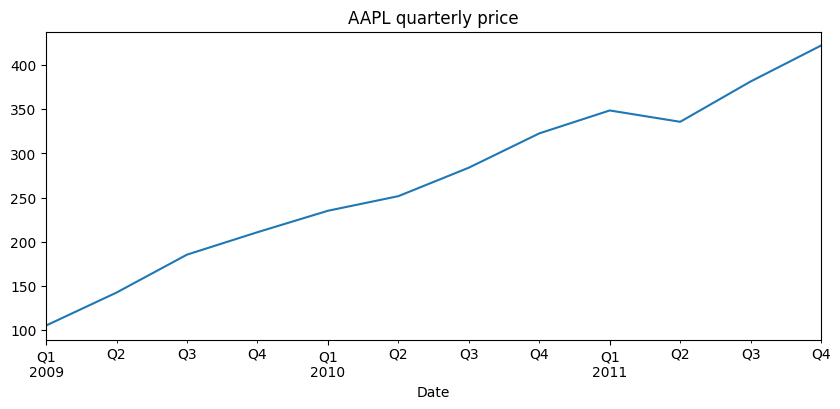

In [57]:
# QE-DEC: 12월을 연말로 보는 분기 단위
appl_q = close_px['AAPL'].resample('QE-DEC').ffill()
appl_q.loc['2009':].plot(title='AAPL quarterly price')
plt.show()

### (3) Moving Window 기능
- `rolling`: 최근 N개 기준
- `expanding`: 시작점부터 누적
- `ewm`: 최근 값에 더 큰 가중치

### (4) 세 가지 이동 창 메소드 비교

- 작은 예제로 결과 차이 확인

In [58]:
df = pd.DataFrame({'B': [0, 1, 2, np.nan, 4]})
df

,B
0,0.0
1,1.0
2,2.0
3,NaN
4,4.0


In [59]:
# 최근 2개씩 묶어 합계 계산
df.rolling(2).sum()

,B
0,NaN
1,1.0
2,3.0
3,NaN
4,NaN


In [60]:
# 처음부터 현재까지 누적 합계 계산
df.expanding(2).sum()

,B
0,NaN
1,1.0
2,3.0
3,3.0
4,7.0


In [61]:
# 최근 값에 더 큰 비중을 둔 평균
df.ewm(com=0.5).mean()

,B
0,0.000000
1,0.750000
2,1.615385
3,1.615385
4,3.670213


In [71]:
df.ewm(com=0.7).mean()

,B
0,0.000000
1,0.708333
2,1.525164
3,1.525164
4,3.476755


### (5) 이동 창 그래프

- 원본 주가와 이동평균 비교
- `window=250`: 최근 250개 관측값 기준

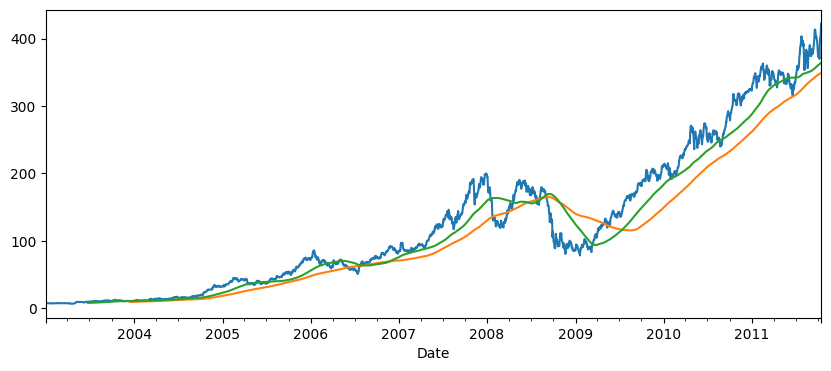

In [78]:
# B: 영업일 기준, window: 이동평균에 사용할 관측값 개수
close_px = close_px.resample('B').ffill()

close_px['AAPL'].plot()
close_px['AAPL'].rolling(window=250, center=False).mean().plot()
close_px['AAPL'].rolling(window=125, center=False).mean().plot()
plt.show()

## 10. 핵심 정리

- 날짜 문자열은 `to_datetime()` 또는 `read_csv(parse_dates=...)`로 날짜형 변환
- 날짜 컬럼은 `.dt`로 연·월·일 등 날짜 속성 추출
- 날짜를 인덱스로 설정하면 기간 선택과 슬라이싱이 쉬움
- `resample()`은 시계열의 시간 단위 변경
  - 다운샘플링: 촘촘한 데이터 → 큰 단위 집계
  - 업샘플링: 큰 단위 데이터 → 촘촘한 날짜 생성
- `rolling`, `expanding`, `ewm`은 이동 창 기반 계산